## Example-63: AT interface

In [1]:
# In this example, lattice conversion to AT is demonstrated
# Twiss parameters are compared for the resulting lattice
# Note, AT dipoles do not have curviliner sextupole component, model dipoles should be set to linear for the result to match

In [2]:
# Import

import torch
from torch import Tensor

from pathlib import Path
from tqdm import tqdm

import matplotlib
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
matplotlib.rcParams['text.usetex'] = True

from model.library.element import Element
from model.library.line import Line
from model.library.corrector import Corrector
from model.library.quadrupole import Quadrupole
from model.library.matrix import Matrix

from model.command.external import load_lattice
from model.command.build import build
from model.command.tune import tune
from model.command.tune import chromaticity
from model.command.orbit import dispersion
from model.command.orbit import ORM
from model.command.twiss import twiss
from model.command.advance import advance
from model.command.coupling import coupling

import at
from model.interface.at import convert

In [3]:
# Set data type and device

Element.dtype = dtype = torch.float64
Element.device = device = torch.device('cpu')

In [4]:
# Load lattice (ELEGANT table)
# Note, lattice is allowed to have repeated elements

path = Path('elettra.lte')
data = load_lattice(path)

In [5]:
# Build and setup lattice

ring:Line = build('RING', 'ELEGANT', data)

# Flatten sublines

ring.flatten()

# Remove all marker elements but the ones starting with MLL (long straight section centers)

ring.remove_group(pattern=r'^(?!MSS_)(?!MLL_).*', kinds=['Marker'])

# Set sextupole integration order and step size

ring.order = (('Sextupole', 1), )
ring.ns = (('Sextupole', 0.01), )

# Set linear dipoles

def apply(element:Element) -> None:
    element.linear = True

ring.apply(apply, kinds=['Dipole'])

# Insert correctors

for name, *_ in ring.layout():
    if name.startswith('CH'):
        corrector = Corrector(f'{name}_CXY', factor=1)
        ring.split((1 + 1, None, [name], None), paste=[corrector])

# Merge drifts

ring.merge()

# Change lattice start start

ring.start = "BPM_S01_01"

# Split BPMs

ring.split((None, ['BPM'], None, None))

# Roll lattice

ring.roll(1)

# Splice

ring.splice()

# Describe

ring.describe

{'BPM': 168,
 'Drift': 744,
 'Dipole': 156,
 'Sextupole': 240,
 'Quadrupole': 120,
 'Corrector': 24,
 'Marker': 24}

In [6]:
# Compute tunes (fractional part)

nux, nuy = tune(ring, [], matched=True, limit=1)

In [7]:
# Compute dispersion

orbit = torch.tensor(4*[0.0], dtype=dtype, device=device)
etaqx, etapx, etaqy, etapy = dispersion(ring, orbit, [], limit=1)

In [8]:
# Compute twiss parameters

ax, bx, ay, by = twiss(ring, [], matched=True, advance=True, full=False).T

In [9]:
# Compute phase advances

mux, muy = advance(ring, [], alignment=False, matched=True).T

In [10]:
# Compute coupling

c = coupling(ring, [])

In [11]:
# Compute chromaticity

psi = chromaticity(ring, [], matched=True)

In [12]:
# Generate AT lattice

lattice = convert(ring, energy=2.4, alignment=False)

In [13]:
# Compute optics

refpts = lattice.uint32_refpts(at.Monitor)
print(len(refpts))
_, ringdata, elemdata = lattice.get_optics(refpts=refpts, get_chrom=True)

168


In [14]:
# Set optics at BPMs

nux_at, nuy_at = ringdata['tune']
psi_at = ringdata['chromaticity']

ax_at, ay_at = elemdata['alpha'].T
bx_at, by_at = elemdata['beta'].T
mux_at, muy_at = elemdata['mu'].T
etaqx_at, etapx_at, etaqy_at, etapy_at = elemdata['dispersion'].T

In [15]:
# Compare tunes

print(nux.numpy(), nuy.numpy())
print(nux_at, nuy_at)
print()

0.2994188531997346 0.160819239377483
0.29936925627927957 0.16081887953270443



In [16]:
# Compare chromaticities

print(psi.numpy())
print(psi_at)
print()

[2.02960315 2.01312355]
[2.02925217 2.01315103]



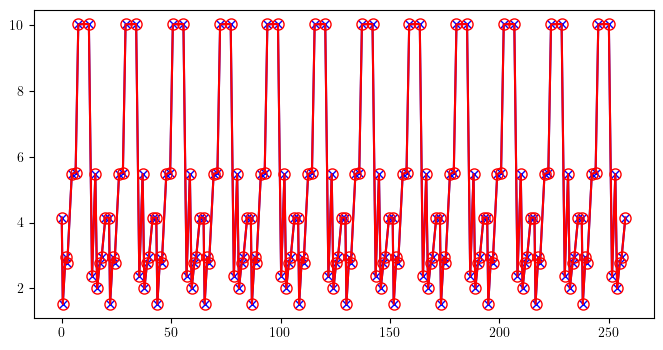

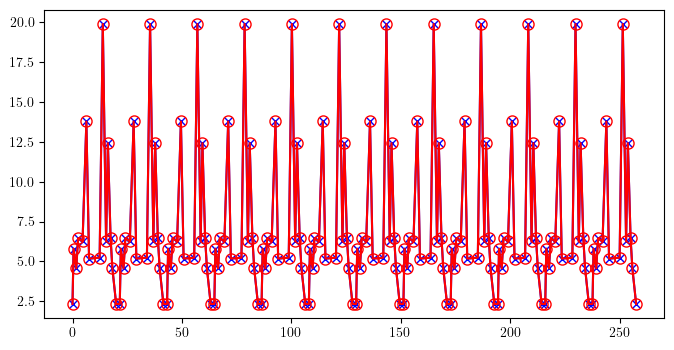

In [17]:
# Compare beta functions

plt.figure(figsize=(8, 4))
plt.errorbar(ring.locations().cpu().numpy(), bx, marker='x', color='blue')
plt.errorbar(ring.locations().cpu().numpy(), bx_at, marker='o', color='red', markerfacecolor='none', ms=8)
plt.show()

plt.figure(figsize=(8, 4))
plt.errorbar(ring.locations().cpu().numpy(), by, marker='x', color='blue')
plt.errorbar(ring.locations().cpu().numpy(), by_at, marker='o', color='red', markerfacecolor='none', ms=8)
plt.show()

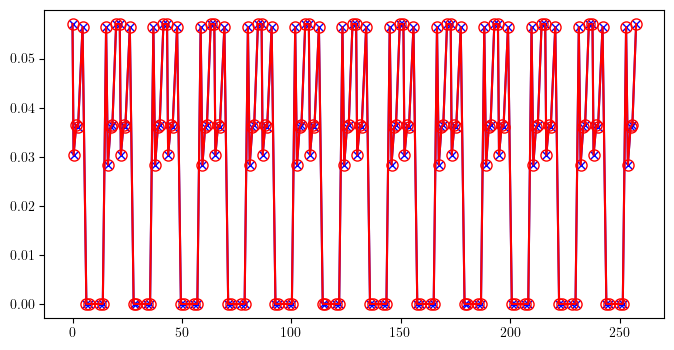

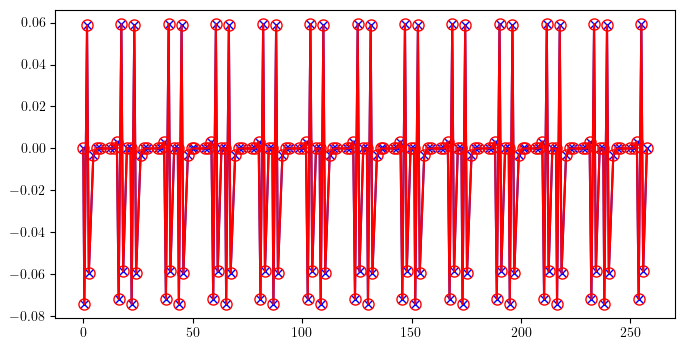

In [18]:
# Compare dispersion functions

plt.figure(figsize=(8, 4))
plt.errorbar(ring.locations().cpu().numpy(), etaqx, marker='x', color='blue')
plt.errorbar(ring.locations().cpu().numpy(), etaqx_at, marker='o', color='red', markerfacecolor='none', ms=8)
plt.show()

plt.figure(figsize=(8, 4))
plt.errorbar(ring.locations().cpu().numpy(), etapx, marker='x', color='blue')
plt.errorbar(ring.locations().cpu().numpy(), etapx_at, marker='o', color='red', markerfacecolor='none', ms=8)
plt.show()